### 1. 그래프의 상태 업데이트
HumanMessage : 사용자(사람)의 메시지 

AIMessage : AI(LLM)의 메시지

AnyMessage : HumanMessage, AIMessage를 포함하는 메시지

ToolMessage: 검색한 결과를 나타내는 메세지



```
딕셔너리 타입
state = {
    "messages" : [],
    "step": 1
}

TypedDict{
    "messages": list,
    "step": int
}
```

### 2. 왜 랭그래프에서 TypedDict을 사용하는 이유
- 랭그래프에서는 State Graph라는 개념이 존재
```
# 노드+노드+노드 -> 이런식으로 연결이 가능
```
- state가 계속 전달된다.

```
# state에는 messages라는 key가 있고, 값은 AnyMessage리스트다.

class state(TypeDict):
    messages: list[AnyMessage] -> 이런식으로 타입을 명확히 전달
```

In [ ]:
from langchain_core.messages import AnyMessage # 랭체인이 당연히 포함
from typing_extensions import TypedDict

class State(TypedDict):
    messages: list[AnyMessage]
    extra_field: int

In [ ]:
from langchain_core.messages import AIMessage

def node(state: State): # 노드 함수에 State값을 받아서 
    messages = state["messages"] # 메세지 속성을 가져와 안에 넣었다가
    new_message = AIMessage("안녕하세요! 무엇을 도와드릴까요?") # AI메세지 안에 새로운 메세지를 만들어서

    # return {"messages": new_message, "extra_field": 10} 
    return {"messages": messages + [new_message], "extra_field": 10} 
# 메세지 속성에 기존 메세지와 새로운 메세지를 더해서 반환한다. 
# extra_field는 10으로 설정한다. 그냥 큰 의미는 없다.

### 상태기반 그래프
StateGraph(State) = state based graph 

이걸로 노드가 연결되는 식으로 chain이 형성된다.

set_entry_point = 시작점을 만든다.

In [ ]:
from langgraph.graph import StateGraph

graph_builder = StateGraph(State) # 랭그래프에서 상태 기반 그래프
graph_builder.add_node("node", node)
# set_entry_point : 그래프의 시작 노드를 지정하는 엣지 (START -> "node")
graph_builder.set_entry_point("node") # 시작점을 만들어준다.

# 랭체인에서 했던 add_edge는 필요없다.
graph = graph_builder.compile() 

graph

In [ ]:
from langchain_core.messages import HumanMessage
# 사람의 메세지를 만드는 클래스

In [ ]:
result = graph.invoke({"messages": [HumanMessage("안녕하세요!")]})
result

In [ ]:
result['messages']
# 메세지 속성에는 기존 메세지와 새로운 메세지가 포함되어 있다.
# 사람의 메세지 ai의 메세지를 any message가 모두 포함한다.

## 대화 메세지 상태 누적 업데이트
<a href =https://reference.langchain.com/python/langgraph/graph/message/add_messages> [add_messages]</a> 는 기존 메시지에서 추가 메시지를 병합하는 데 사용하는 함수로, 새로 들어온 메시지를 추가할 때 사용할 수 있는 리듀서 역할(합치는 함수)

In [ ]:
from typing_extensions import Annotated
from langgraph.graph.message import add_messages

In [ ]:
class State(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages] 
    extra_field: int

In [ ]:
def node(state: State):
    messages = state["messages"]  # state에서 messages를 가져온다.
    new_message = AIMessage("안녕하세요! 무엇을 도와드릴까요?") 

    return {"messages": new_message, "extra_field": 10}

In [ ]:
from langgraph.graph import StateGraph

graph_builder = StateGraph(State)
graph_builder.add_node("node", node)
graph_builder.set_entry_point("node")
graph = graph_builder.compile()

graph

### role: 종류
user: 사용자 메세지

assistant: AI메세지

system: 시스템 지시

tool: 도구 결과

In [ ]:
input_message = {"role": "user", "content": "안녕하세요!"} # 안녕하세요 라고 user가 말함.
# invoke 그래프 실행함수.
result = graph.invoke({"messages": [input_message]})

for message in result["messages"]:
# pretty_print()는 데이터나 객체를 보기 좋게(Pretty) 정리해서 출력하는 함수
    message.pretty_print()

다음달에 LLM연결이 필요해서 신용카드(체크카드 필요)

In [ ]:
result['messages']

ainvoke: 비동기 처리로 여러 요청을 동시에 보낼 수 있음
- 비동기: 나중에 처리해도 돼. 즉, 병렬적으로 다른것도 함께 처리
```
await graph.ainvoke({"messages": [input_message]})
```

invoke: 하나의 요청에 대한 결과를 받을 때 까지 코드 실행을 멈춤. 한번에 하나의 요청을 처리
- 동기: 이거 끝내고 가야해, 즉, 직렬적으로 해야함.
```
graph.invoke({"messages": [input_message]})
```

stream: 중간 결과를 실시간으로 반환함. (단계별로 반환)
- stream_mode="values" 각 단계의 현재 상태 값 출력
- Default) stream_mode="updates" 각 단계의 상태 업데이트만 출력
- stream_mode="messages" 각 단계의 메시지 출력
```
for chunk in graph.stream({"messages": [input_message]}, stream_mode="values"):
    print(chunk)
    for state_key, state_value in chunk.items():
        if state_key == "messages":
            state_value[-1].pretty_print()
```


In [ ]:
for chunk in graph.stream({"messages": [input_message]}, stream_mode="values"):
    print(chunk)
    for state_key, state_value in chunk.items():
        if state_key == "messages":
            state_value[-1].pretty_print() # 맨 마지막 메세지

In [ ]:
for chunk in graph.stream({"messages": [input_message]}, stream_mode="updates"):
    print(chunk)
    for node, value in chunk.items():
        if node:
            print(node)
        if "messages" in value:
            print(value['messages'].content)


In [ ]:
for chunk_msg, metadata in graph.stream({"messages": [input_message]}, stream_mode="messages"):
    print(chunk_msg)
    print(chunk_msg.content) # .으로 접근하거나
    print(metadata)
    print(metadata["langgraph_node"]) # 대괄호로 키 값으로 접근하거나 둘 다 가능하다.

In [ ]:
async for chunk_msg, metadata in graph.astream({"messages": [input_message]}, stream_mode="messages"):
    print(chunk_msg)
    print(chunk_msg.content)
    print(metadata)
    print(metadata["langgraph_node"])

In [ ]:
from typing_extensions import TypedDict

class State(TypedDict):
    value_1: str
    value_2: int

In [ ]:
def step_1(state: State):
    return {"value_1": state["value_1"]}

def step_2(state: State):
    current_value_1 = state["value_1"]
    return {"value_1": f"{current_value_1} b"}

def step_3(state: State):
    return {"value_2": 10}

In [ ]:
from langgraph.graph import START, StateGraph

graph_builder = StateGraph(State)

# 노드 추가
graph_builder.add_node(step_1)
graph_builder.add_node(step_2)
graph_builder.add_node(step_3)

# 엣지 추가
graph_builder.add_edge(START, "step_1") # START ->1
graph_builder.add_edge("step_1", "step_2") # 1->2
graph_builder.add_edge("step_2", "step_3") # 2->3

In [ ]:
graph = graph_builder.compile()
graph

In [ ]:
graph_builder = StateGraph(State).add_sequence([step_1, step_2, step_3])
graph_builder.add_edge(START, "step_1") # START ->1
graph = graph_builder.compile()

graph.invoke({"value_1": "c"}) # value_1이 c로 시작해서 step_1에서 c가 되고 step_2에서 cb가 되고 step_3에서 value_2가 10이 된다.

# 병렬연결

In [ ]:
import operator
from typing import Annotated, Any
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END

class State(TypedDict):
    aggregate: Annotated[list, operator.add] # 업데이트 값이 뒤에 추가되도록 하는 operator.add 리듀서

aggregate: 병합을 할지 말지 정하는 reducer역할을 함


In [ ]:
def a(state: State):
    print(f'Adding "A" to {state["aggregate"]}')
    return {"aggregate": ["A"]}

def b(state: State):
    print(f'Adding "B" to {state["aggregate"]}')
    return {"aggregate": ["B"]}

def c(state: State):
    print(f'Adding "C" to {state["aggregate"]}')
    return {"aggregate": ["C"]}

def d(state: State):
    print(f'Adding "D" to {state["aggregate"]}')
    return {"aggregate": ["D"]}

In [ ]:
graph_builder = StateGraph(State)

# 노드 추가
graph_builder.add_node(a)
graph_builder.add_node(b)
graph_builder.add_node(c)
graph_builder.add_node(d)

In [ ]:
# 엣지 추가
graph_builder.add_edge(START, "a")
graph_builder.add_edge("a", "b") # a -> b
graph_builder.add_edge("a", "c") # a -> c
graph_builder.add_edge("b", "d") # b -> d
graph_builder.add_edge("c", "d") # c -> d
graph_builder.add_edge("d", END)
graph = graph_builder.compile()

# 지금은 그림만 그리므로 잘못되어도 에러가 나지 않지만, 실제로 작동하면 에러가 날수 있다..
# end포인트가 여러개 있을 수도 있다.(문서가 나와야하는 방향, 사용자에게 보여지는 방향, 실제로 데이터가 흘러가는 방향 등) 
graph

In [ ]:
graph.invoke({"aggregate":[]})

# 조건부 엣지 병렬연결

In [ ]:
import operator
from typing import Annotated, Sequence
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END

class State(TypedDict):
    aggregate: Annotated[list, operator.add]
    which: str

In [ ]:
def a(state: State):
    print(f'Adding "A" to {state["aggregate"]}')
    return {"aggregate": ["A"]}

def b(state: State):
    print(f'Adding "B" to {state["aggregate"]}')
    return {"aggregate": ["B"]}

def c(state: State):
    print(f'Adding "C" to {state["aggregate"]}')
    return {"aggregate": ["C"]}

def d(state: State):
    print(f'Adding "D" to {state["aggregate"]}')
    return {"aggregate": ["D"]}

def e(state: State):
    print(f'Adding "E" to {state["aggregate"]}')
    return {"aggregate": ["E"]}

In [ ]:
graph_builder = StateGraph(State)
graph_builder.add_node(a)
graph_builder.add_node(b)
graph_builder.add_node(c)
graph_builder.add_node(d)
graph_builder.add_node(e)
graph_builder.add_edge(START, "a")

In [ ]:
# bc 혹은 cd 로 라우트를 결정하는 함수
def route_bc_or_cd(state: State) -> Sequence[str]:
    if state["which"] == "cd":
        return ["c", "d"]
    return ["b", "c"]

intermediates = ["b", "c", "d"]
# add_conditional_edges는 조건부 엣지를 추가하는 함수로,
#  "a" 노드에서 route_bc_or_cd 함수를 통해 반환된 노드들로 라우팅하는 엣지를 추가한다.
graph_builder.add_conditional_edges(
    "a",
    route_bc_or_cd,
    intermediates
)

In [ ]:
for node in intermediates:
    graph_builder.add_edge(node, "e")

graph_builder.add_edge("e", END)
graph = graph_builder.compile()
graph

In [ ]:
graph.invoke({"aggregate": [], "which": "bc"})

In [ ]:
graph.invoke({"aggregate": [], "which": "cd"})

# 조건과 반복

In [ ]:
import operator
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END

class State(TypedDict):
    aggregate: Annotated[list, operator.add]

In [ ]:
def a(state: State):
    print(f'Node A 처리 중 현재 상태값 : {state["aggregate"]}')
    return {"aggregate": ["A"]}


def b(state: State):
    print(f'Node B 처리 중 현재 상태값 : {state["aggregate"]}')
    return {"aggregate": ["B"]}


graph_builder = StateGraph(State)
graph_builder.add_node(a)
graph_builder.add_node(b)

In [ ]:
def route(state: State):
    if len(state["aggregate"]) < 7:
        return "b"
    else:
        return END
    
graph_builder.add_edge(START, "a")
graph_builder.add_conditional_edges("a", route)
graph_builder.add_edge("b", "a")
graph = graph_builder.compile()

In [ ]:
import requests, zlib, base64
from IPython.display import Image

# Mermaid 코드 추출
code = graph.get_graph().draw_mermaid()

# 압축·인코딩 후 Kroki 요청
encoded = base64.urlsafe_b64encode(zlib.compress(code.encode())).decode()
# encode : 인코딩 compress: 압축

url = f"https://kroki.io/mermaid/png/{encoded}"
resp = requests.get(url)
display(Image(resp.content))

In [ ]:
graph.invoke({"aggregate": []})

In [ ]:
from langgraph.errors import GraphRecursionError
# GraphRecursionError 로 에러를 반환하는 방법
try:
    graph.invoke({"aggregate": []}, config={"recursion_limit": 4})
except GraphRecursionError: # 반복 종료 조건에 도달할 수 없는 경우
    print("Recursion Error")

# 8. 조건에 따른 반복 처리하기
<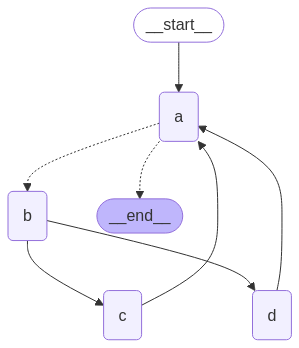>

In [ ]:
import operator
from typing import Annotated, Literal
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END

class State(TypedDict):
    aggregate: Annotated[list, operator.add]

In [ ]:
def a(state: State):
    print(f'Node A 처리 중 현재 상태값 : {state["aggregate"]}')
    return {"aggregate": ["A"]}

def b(state: State):
    print(f'Node B 처리 중 현재 상태값 : {state["aggregate"]}')
    return {"aggregate": ["B"]}

def c(state: State):
    print(f'Node C 처리 중 현재 상태값 : {state["aggregate"]}')
    return {"aggregate": ["C"]}

def d(state: State):
    print(f'Node D 처리 중 현재 상태값 : {state["aggregate"]}')
    return {"aggregate": ["D"]}

graph_builder = StateGraph(State)
graph_builder.add_node(a)
graph_builder.add_node(b)
graph_builder.add_node(c)
graph_builder.add_node(d)


In [ ]:
def route(state: State) -> Literal['b', END]:
    # ["A", "B", "C"] -> 3
    if len(state['aggregate']) < 7: # 딱히 의미는 없음 그래프대로 나눠주기 위함
        return "b"
    else:
        return END
    
graph_builder.add_edge(START, "a")  # START -> a
graph_builder.add_conditional_edges("a", route) # a -> b 혹은 a -> END
graph_builder.add_edge("b", "c") # b -> c
graph_builder.add_edge("b", "d") # b -> d
graph_builder.add_edge(["c", "d"], "a")  # c -> a, d -> a 
graph = graph_builder.compile()

In [ ]:
result = graph.invoke({"aggregate": []})

# 9. 사용자 입력에 따른 반복 조건 설정
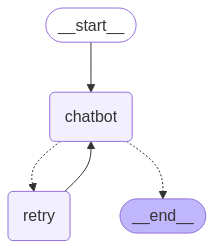


In [ ]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langchain_core.messages import AIMessage, HumanMessage
from langgraph.graph.message import add_messages

In [ ]:
class State(TypedDict):
    human_messages: Annotated[list[HumanMessage], add_messages] # HumanMessage리스트에 add_messages 리듀서를 적용하여 업데이트된 메세지를 기존 메세지에 추가하는 방식 
    ai_messages: Annotated[list[AIMessage], add_messages]
    retry_num : int

In [ ]:
def chatbot(state:State):
    retry_num = state["retry_num"]
    user_input = input(f'현재 {retry_num}회 재시도 중입니다. 사용자 입력: ') # 사용자로부터 입력을 받는다.
    ai_message = AIMessage(f'{retry_num}번째 답변 중')
    return {"human_messages": [HumanMessage(user_input)], "ai_messages": [ai_message], "retry_num": retry_num}

In [ ]:
def retry(state: State):
    return {"retry_num": state["retry_num"] + 1}

graph_builder = StateGraph(State)
graph_builder.add_node("chatbot", chatbot)
graph_builder.add_node("retry", retry)

In [ ]:
def route(state: State):
    if "반복" in state["human_messages"][-1].content:
        return "retry"
    else:
        return END

In [ ]:
graph_builder.add_edge(START, "chatbot")
graph_builder.add_conditional_edges("chatbot", route)
graph_builder.add_edge("retry", "chatbot")
graph = graph_builder.compile()


In [ ]:
for chunk in graph.stream({"human_messages": "반복", "retry_num": 0}, stream_mode="updates"):
    print(chunk)
    for node, value in chunk.items():
        if node:
            print(node)
        if "messages" in value:
            print(value['messages'].content)

그러면 해당 그래프를 적용해 ai가 메세지를 생성한다면, ai_messages엔 LLM이 만든 메세지가 retry_num만큼 쌓여있고, human_messages에도 retry_num만큼 사람이 적은게 쌓여있게 됨.

In [ ]:
graph.invoke({"human_messages": "반복", "retry_num": 0})

In [ ]:
graph